## Define functions

In [2]:
import numpy as np
import pandas as pd
import os

# --- Load Data ---
def load_data(file_path):
    """
    Loads timestamped accelerometer data from a CSV file.

    Args:
        file_path (str): Path to the input data file.

    Returns:
        pd.DataFrame: DataFrame containing columns ['x', 'y', 'z', 'timestamp'].
    """
    return pd.read_csv(file_path, names=['x', 'y', 'z', 'timestamp'])

# --- Interpolation Method ---
def align_by_interpolation(ref_df, align_df):
    """
    Aligns align_df to ref_df's timestamps using linear interpolation.

    Args:
        ref_df (pd.DataFrame): Reference dataframe with target timestamps.
        align_df (pd.DataFrame): Dataframe to align using interpolation.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: (ref_df, interpolated_aligned_df)
    """
    interp_df = pd.DataFrame()
    interp_df['timestamp'] = ref_df['timestamp']
    interp_df['x'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['x'])
    interp_df['y'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['y'])
    interp_df['z'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['z'])
    interp_df = interp_df[['x', 'y', 'z', 'timestamp']]
    return ref_df, interp_df

# --- Save Aligned Data ---
def save_aligned_data(df_55, df_193, output_path):
    """
    Saves aligned data from two dataframes into a single CSV file in the order 55 then 193.

    Args:
        df_55 (pd.DataFrame): Aligned data from device 55.
        df_193 (pd.DataFrame): Aligned data from device 193.
        output_path (str): Path to save the output file.
    """
    aligned = pd.concat([df_55.add_suffix('_1'), df_193.add_suffix('_2')], axis=1)
    aligned.to_csv(output_path, index=False)
    print(f"Saved aligned data to {output_path}")

# --- Load, align and save ---
def load_align_save(distance):
    """
    Loads, aligns, and saves accelerometer data for multiple pairs of recordings,
    always saving in the order (55, 193) but aligning using the device with fewer samples.

    Args:
        distance (str): Distance label used in filenames (e.g., '50', '155').
    """
    for i in range(1, 6):
        df_55 = load_data(f'{distance}_{i}_55.txt')
        df_193 = load_data(f'{distance}_{i}_193.txt')

        # Prevent extrapolation by choosing the smaller one as reference
        if len(df_55) <= len(df_193):
            ref_df, aligned_df = align_by_interpolation(df_55, df_193)
        else:
            ref_df, aligned_df = align_by_interpolation(df_193, df_55)

        # Ensure df_55 is always saved as _1 and df_193 as _2
        if ref_df.equals(df_55):
            save_aligned_data(ref_df, aligned_df, f'aligned_{distance}_{i}.txt')
        else:
            save_aligned_data(aligned_df, ref_df, f'aligned_{distance}_{i}.txt')


def load_all_aligned_data_to_dict(file_prefixes):
    """
    Loads all aligned data files matching each prefix into a dictionary of DataFrames.
    
    Args:
        file_prefixes (List[str]): List of file name prefixes (e.g., ['263', 'static']).
    
    Returns:
        Dict[str, pd.DataFrame]: Dictionary of label -> DataFrame.
    """
    dfs = {}
    for prefix in file_prefixes:
        for i in range(1, 6):
            file_path = f'aligned_{prefix}_{i}.txt'
            if os.path.exists(file_path):
                df = pd.read_csv(file_path, names=[
                    'x1', 'y1', 'z1', 'timestamp1', 'x2', 'y2', 'z2', 'timestamp2'
                ], dtype=str)  # Read as string first to avoid DtypeWarning

                # Convert all columns to numeric safely
                for col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')

                # Drop any rows with NaNs if needed
                df = df.dropna().reset_index(drop=True)

                key = f"{prefix}_{i}"
                dfs[key] = df
            else:
                print(f"File not found: {file_path}")
    return dfs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


def preamplify(data, gain_dB):
    gain = 10**(gain_dB / 20)
    return data * gain


def anti_alias_filter(data, cutoff_freq, Fs, order=4):
    nyq = 0.5 * Fs
    normal_cutoff = cutoff_freq / nyq
    b, a = signal.butter(order, normal_cutoff, btype='lowpass')
    return signal.filtfilt(b, a, data)


def hpf(data, cutoff_freq, Fs, order):
    nyq = 0.5 * Fs
    normal_cutoff = cutoff_freq / nyq
    b, a = signal.butter(order, normal_cutoff, btype='highpass')
    return signal.filtfilt(b, a, data)


def analyze_tdoa_location(data_dict, Fs=3200, hpf_cutoff=30, anti_alias_cutoff=1400, gain_dB=20):
    pvc_speed = 2395  # m/s
    water_speed = 1482  # m/s
    sensor_distance = 3.5  # meters

    for label, df in data_dict.items():
        # Compute total acceleration
        a1 = np.sqrt(df['x1']**2 + df['y1']**2 + df['z1']**2)
        a2 = np.sqrt(df['x2']**2 + df['y2']**2 + df['z2']**2)

        Fs = len(a1) / 30

        # Apply preamplification
        # a1 = preamplify(a1, gain_dB)
        # a2 = preamplify(a2, gain_dB)

        # Anti-aliasing filter
        # a1 = anti_alias_filter(a1, anti_alias_cutoff, Fs)
        # a2 = anti_alias_filter(a2, anti_alias_cutoff, Fs)

        # High-pass filter
        a1 = hpf(a1, hpf_cutoff, Fs, 4)
        a2 = hpf(a2, hpf_cutoff, Fs, 4)

        # Compute CSD (complex)
        f, t, csd = signal.spectrogram(a1, Fs, nperseg=512, noverlap=256, mode='complex')
        _, _, csd_2 = signal.spectrogram(a2, Fs, nperseg=512, noverlap=256, mode='complex')

        # Cross-spectrum
        csd = csd * np.conj(csd_2)

        # Limit frequency range to 0~1200 Hz
        freq_mask = f <= 1200
        f = f[freq_mask]
        csd = csd[freq_mask, :]

        # Find max magnitude and corresponding time and frequency
        max_idx = np.unravel_index(np.argmax(np.abs(csd)), csd.shape)
        max_freq = f[max_idx[0]]
        max_time = t[max_idx[1]]

        # Estimate time delay using cross-correlation
        corr = signal.correlate(a2, a1, mode='full')
        lag = np.argmax(corr) - (len(a1) - 1)
        time_delay = lag / Fs

        # Estimate source location for PVC and water
        location = sensor_distance/2 - pvc_speed * time_delay
        # location_water = sensor_distance - water_speed * time_delay

        # Plotting
        fig, axs = plt.subplots(2, 1, figsize=(10, 8))
        fig.suptitle(f"Analysis for {label}\nEstimated Source: PVC ~ {location:.2f} m",
                     fontsize=12, color='black', y=0.98)

        # Plot CSD Spectrogram
        T, F = np.meshgrid(t, f)
        mesh = axs[0].pcolormesh(F, T, np.abs(csd), shading='auto', cmap='viridis')
        axs[0].set_xlim([100, 1200])
        fig.colorbar(mesh, ax=axs[0], label='CSD Magnitude')
        axs[0].set_xscale('log')
        axs[0].set_xlabel('Frequency (Hz)')
        axs[0].set_ylabel('Time (s)')
        axs[0].set_title('CSD Spectrogram')

        # Annotate max point on spectrogram
        axs[0].annotate(f'Max: {max_freq:.1f} Hz @ {max_time:.2f} s',
                        xy=(max_freq, max_time),
                        xytext=(max_freq, max_time + 0.05),
                        arrowprops=dict(facecolor='red', shrink=0.05),
                        color='red')

        # Plot Cross-correlation
        lags = np.arange(-len(a1) + 1, len(a1)) / Fs
        axs[1].plot(lags, corr)
        axs[1].axvline(time_delay, color='red', linestyle='--', label=f'Time Delay: {time_delay:.4f} s')
        axs[1].axvline(0, color='black', linewidth=0.5)
        axs[1].set_xlabel('Lag (s)')
        axs[1].set_ylabel('Cross-correlation')
        axs[1].set_title('Cross-correlation between Sensor 2 and Sensor 1')
        axs[1].legend()
        axs[1].grid(True)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

        # Print source location info
        print(f"[{label}] Estimated Time Delay: {time_delay} s")
        print(f"[{label}] Estimated Source Location:")
        print(f"  PVC speed ({pvc_speed} m/s): {location:.2f} m")


## Import and Align data

In [31]:
import pandas as pd

load_align_save(263)
load_align_save(155)
# load_align_save(50)
# load_align_save('static')

Saved aligned data to aligned_263_1.txt
Saved aligned data to aligned_263_2.txt
Saved aligned data to aligned_263_3.txt
Saved aligned data to aligned_263_4.txt
Saved aligned data to aligned_263_5.txt
Saved aligned data to aligned_155_1.txt
Saved aligned data to aligned_155_2.txt
Saved aligned data to aligned_155_3.txt
Saved aligned data to aligned_155_4.txt
Saved aligned data to aligned_155_5.txt


## Analyze data and Plotting

In [32]:
file_prefixes = ['263', '155', '50', 'static']
data_dict = load_all_aligned_data_to_dict(file_prefixes)


ValueError: x and y must have same first dimension, but have shapes (192063,) and (1,)

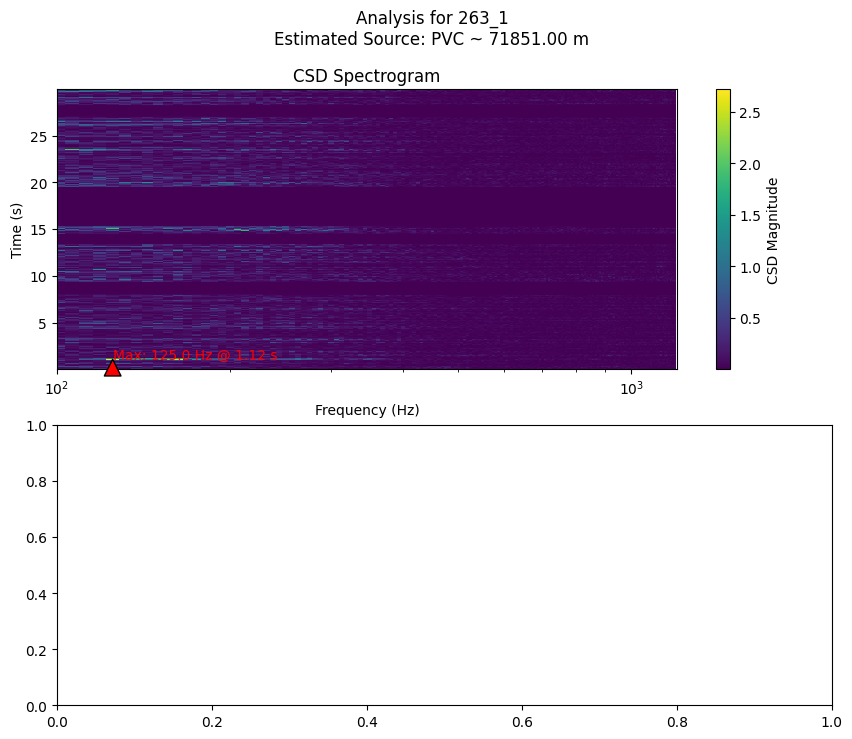

In [44]:
csd_results = analyze_tdoa_location(data_dict)